Loading and preparing data...
Train shape: (26304, 10), Test shape: (6576, 10)
Features used: ['cow.1', 'hour', 'IN_ALLEYS', 'REST', 'EAT', 'ACTIVITY_LEVEL', 'rest_to_eat_ratio', 'hour_sin', 'hour_cos', 'activity_rest_ratio']
Training TabNet model...


C:\Users\vishn\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.41342 | train_auc: 0.65876 | valid_auc: 0.64867 |  0:00:02s
epoch 1  | loss: 0.31325 | train_auc: 0.69552 | valid_auc: 0.69306 |  0:00:05s
epoch 2  | loss: 0.30568 | train_auc: 0.7     | valid_auc: 0.69181 |  0:00:07s
epoch 3  | loss: 0.30331 | train_auc: 0.71487 | valid_auc: 0.70202 |  0:00:10s
epoch 4  | loss: 0.3023  | train_auc: 0.71602 | valid_auc: 0.70607 |  0:00:13s
epoch 5  | loss: 0.3001  | train_auc: 0.71979 | valid_auc: 0.70372 |  0:00:16s
epoch 6  | loss: 0.29979 | train_auc: 0.7232  | valid_auc: 0.71306 |  0:00:18s
epoch 7  | loss: 0.29952 | train_auc: 0.72105 | valid_auc: 0.71    |  0:00:21s
epoch 8  | loss: 0.30002 | train_auc: 0.72413 | valid_auc: 0.71288 |  0:00:24s
epoch 9  | loss: 0.2985  | train_auc: 0.72455 | valid_auc: 0.70955 |  0:00:26s
epoch 10 | loss: 0.29755 | train_auc: 0.73255 | valid_auc: 0.71519 |  0:00:29s
epoch 11 | loss: 0.29721 | train_auc: 0.73517 | valid_auc: 0.71898 |  0:00:32s
epoch 12 | loss: 0.29667 | train_auc: 0.7339  | vali

C:\Users\vishn\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Training completed in 277.97 seconds
Successfully saved model at tabnet_multioutput_model.zip
Model and scaler saved

Evaluating on test set...

OESTRUS PERFORMANCE
              precision    recall  f1-score   support

           0       0.80      0.94      0.87      4987
           1       0.62      0.28      0.38      1589

    accuracy                           0.78      6576
   macro avg       0.71      0.61      0.63      6576
weighted avg       0.76      0.78      0.75      6576


CALVING PERFORMANCE
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      5668
           1       0.74      0.40      0.52       908

    accuracy                           0.90      6576
   macro avg       0.82      0.69      0.73      6576
weighted avg       0.89      0.90      0.88      6576


LAMENESS PERFORMANCE
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      5912
           1       0.69      

C:\Users\vishn\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vishn\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vishn\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Training history plot saved as tabnet_training_history.png


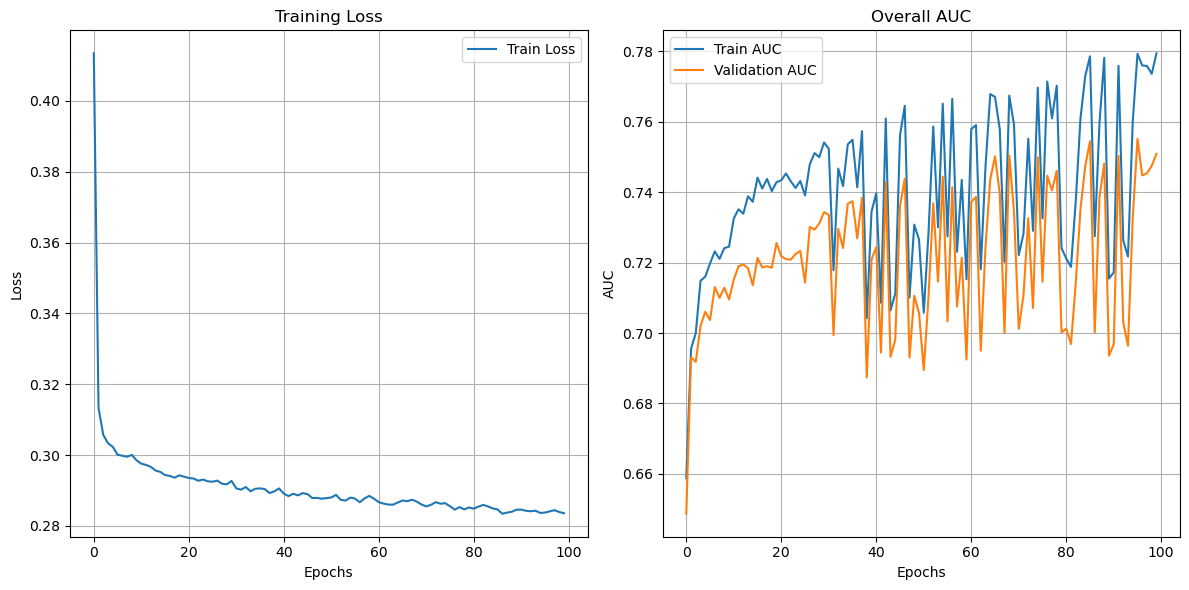

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabnet.multitask import TabNetMultiTaskClassifier
import joblib
import time
import matplotlib.pyplot as plt

# 1. Load and prepare data
print("Loading and preparing data...")
df = pd.read_csv('balanced_datasets/multi_output_balanced.csv')

# Feature engineering
df['activity_rest_ratio'] = df['ACTIVITY_LEVEL'] / (df['REST'] + 1e-6)

# Remove problematic features
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 1', 'disturbance', 'cow', 'date', 'any_disease'])

# Separate features and targets
X = df.drop(columns=['oestrus', 'calving', 'lameness', 'mastitis'])
y = df[['oestrus', 'calving', 'lameness', 'mastitis']].values.astype(int)

# Identify categorical features (none for now)
categorical_columns = []
categorical_dims = []

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y[:, 0]  # Stratify by oestrus
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Features used: {list(X.columns)}")

# 2. Preprocessing
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. Define TabNet model with optimized parameters
clf = TabNetMultiTaskClassifier(
    n_d=64, 
    n_a=64, 
    n_steps=3,  # Reduced steps for faster training
    gamma=1.3, 
    n_independent=1, 
    n_shared=2,
    cat_idxs=categorical_columns,
    cat_dims=categorical_dims,
    lambda_sparse=1e-4,
    momentum=0.7,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2, weight_decay=1e-5),
    scheduler_params={"step_size": 15, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type="entmax",
    device_name='cuda' if torch.cuda.is_available() else 'cpu',
    verbose=1
)

# 4. Train the model
print("Training TabNet model...")
start_time = time.time()

clf.fit(
    X_train=X_train, 
    y_train=y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_name=['train', 'valid'],
    eval_metric=['auc'],
    max_epochs=100,  # Reduced epochs
    patience=20,     # Increased patience
    batch_size=2048, # Larger batch size
    virtual_batch_size=512,
    num_workers=0,
    drop_last=False,
)

print(f"Training completed in {time.time()-start_time:.2f} seconds")

# 5. Save the model
clf.save_model('tabnet_multioutput_model')
joblib.dump(scaler, 'tabnet_scaler.joblib')
print("Model and scaler saved")

# 6. Evaluate on test set
print("\nEvaluating on test set...")
# Get predictions and probabilities
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)

# Classification report for each disease
diseases = ['oestrus', 'calving', 'lameness', 'mastitis']
test_results = {}

for i, disease in enumerate(diseases):
    print(f"\n{'='*50}\n{disease.upper()} PERFORMANCE\n{'='*50}")
    
    # Get true labels for this disease and ensure integer type
    y_true = y_test[:, i].astype(int)
    
    # Get predictions for this disease and ensure integer type
    y_pred_i = y_pred[i].astype(int)
    
    # Get probabilities for positive class
    y_proba_i = y_proba[i][:, 1]
    
    # Print classification report
    print(classification_report(y_true, y_pred_i))
    
    # Calculate and store AUC
    test_results[disease] = {
        'auc': roc_auc_score(y_true, y_proba_i)
    }

# 7. Feature importance analysis
print("\nFeature Importances:")
feature_importances = clf.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("\nTop Features:")
print(importance_df.head(10))

# 8. Final summary
print("\n" + "="*50)
print("FINAL MODEL SUMMARY")
print("="*50)
print(f"Number of epochs: {clf.best_epoch}")
print(f"Best validation AUC: {clf.best_cost:.4f}")

for disease in diseases:
    print(f"{disease.upper()} Test AUC: {test_results[disease]['auc']:.4f}")

# 9. Visualization of training metrics
plt.figure(figsize=(12, 6))

# Plot losses
plt.subplot(1, 2, 1)
plt.plot(clf.history['loss'], label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot overall AUC
plt.subplot(1, 2, 2)
plt.plot(clf.history['train_auc'], label='Train AUC')
plt.plot(clf.history['valid_auc'], label='Validation AUC')
plt.title('Overall AUC')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('tabnet_training_history.png')
print("\nTraining history plot saved as tabnet_training_history.png")